# Generate Dissertation Figures

Generates all publication-quality figures for the dissertation.

**Figures:**
1. `fig_training_curves.png` — Fold 5 training curves (loss + F1)
2. `fig_comparison.png` — Method comparison bar chart
3. `fig_pipeline.png` — Pipeline overview diagram
4. `fig_map.png` — Geographic map of scene performance
5. `fig_timeline.png` — Acquisition timeline of scene performance
6. `fig_per_scene_scatter.png` — Per-scene F1 vs water fraction scatter
7. `fig_qualitative.png` — Qualitative predictions panel (best/worst/confounded)

**Author:** Luana Marotti | 2026

In [1]:
# ── Cell 1: Setup ──
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import rasterio
from pathlib import Path

BASE_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
KFOLD_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
DIAG_DIR  = BASE_DIR / 'results/unet_diagnostic_v3'
ANALYSIS_DIR = BASE_DIR / 'results/dataset_analysis'
CHIPS_DIR = BASE_DIR / 'images/chips_images/images'
MASKS_DIR = BASE_DIR / 'images/chips_masks/masks'
NDWI_MASKS_DIR = BASE_DIR / 'results/ndwi_chips/masks_t0.35'
OWM_DIR   = BASE_DIR / 'results/owm_chips'
PROB_DIR_BEST     = DIAG_DIR / 'prob_maps_best'
PRED_DIR_MAJORITY = DIAG_DIR / 'pred_maps_ensemble_majority'
OUT_DIR   = BASE_DIR / 'results/dissertation_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ──
plt.rcParams.update({
    'font.family':     'Times New Roman',
    'font.size':       9,
    'axes.titlesize':  9,
    'axes.labelsize':  9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi':      300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
ORANGE = '#e07b00'
GRAY   = '#73726c'
LGRAY  = '#c3c2b7'
RED    = '#c0392b'

print(f'Output directory: {OUT_DIR}')

Output directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures


Loaded 203 epochs from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold5_history.csv


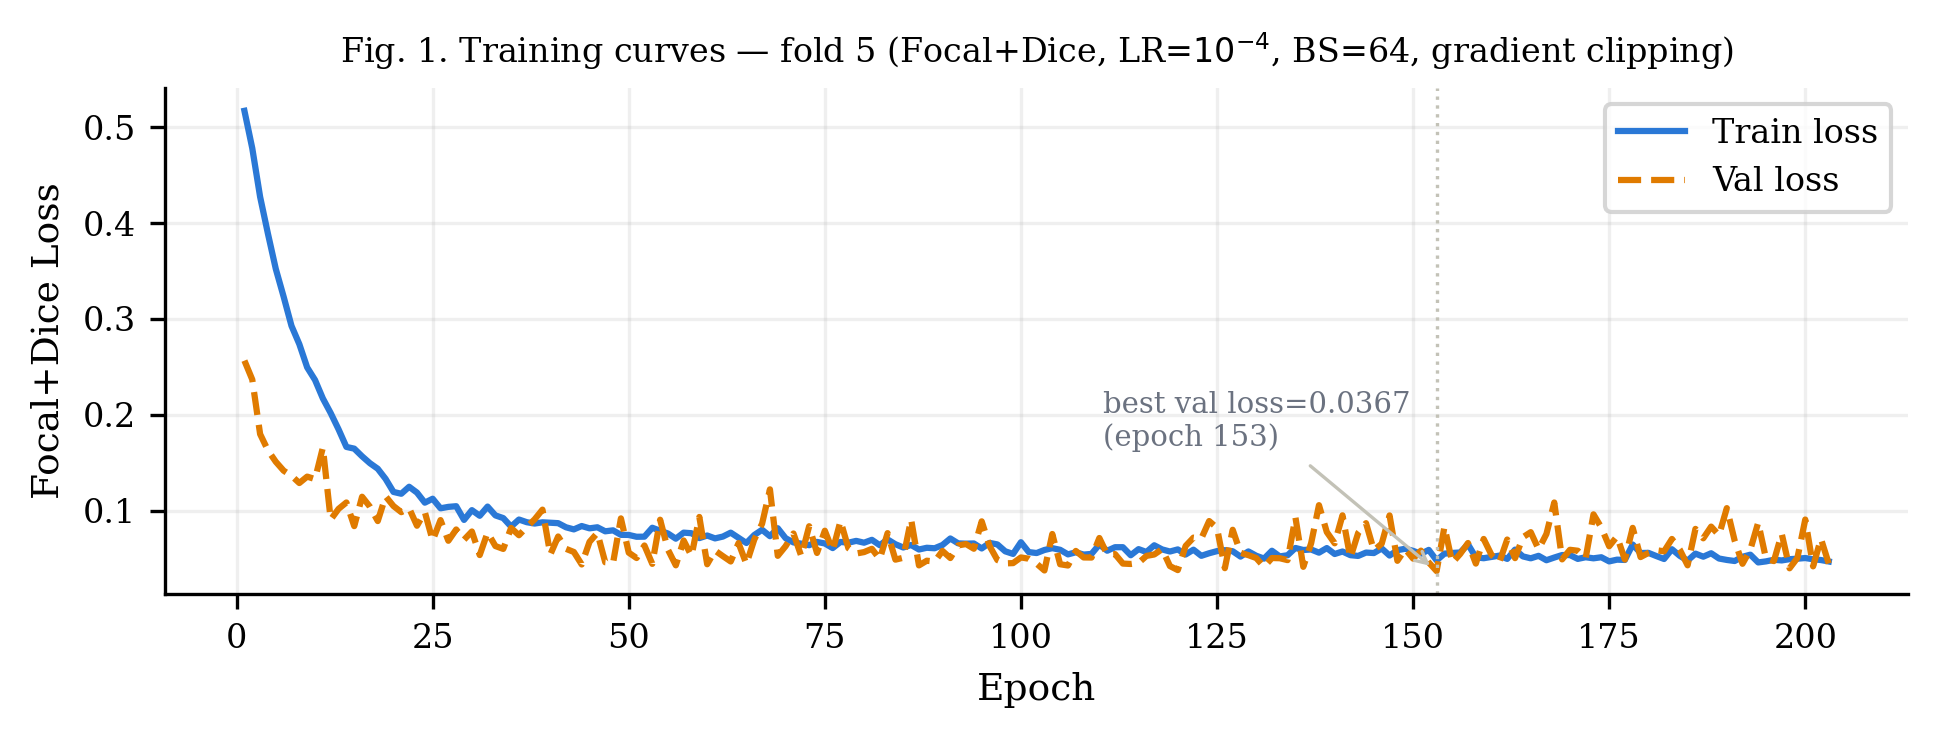

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_training_curves.png


In [20]:
# ── Cell 2: Fig 1 — Training Curves (Fold 5, loss only) ──

candidate_paths = [
    KFOLD_DIR / 'fold5_history.csv',
    KFOLD_DIR / 'fold5_log.csv',
    KFOLD_DIR / 'fold_5_history.csv',
    BASE_DIR / 'results/unet_training_v3/sweep_lr1e4_test/Ctest_lr1e4_focal_dice_history.csv',
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    available = [f.name for f in KFOLD_DIR.glob('*.csv')] if KFOLD_DIR.exists() else []
    raise FileNotFoundError(
        'No training history CSV found. Checked candidate paths:\n  '
        + '\n  '.join(str(p) for p in candidate_paths)
        + f'\nAvailable CSVs in {KFOLD_DIR}: {available}'
    )
df = pd.read_csv(csv_path)
print(f'Loaded {len(df)} epochs from {csv_path}')

best_loss_ep = df.loc[df['val_loss'].idxmin(), 'epoch']
best_loss    = df['val_loss'].min()

fig, ax = plt.subplots(1, 1, figsize=(6.5, 2.5))

ax.plot(df['epoch'], df['train_loss'], color=BLUE,   lw=1.5, label='Train loss')
ax.plot(df['epoch'], df['val_loss'],   color=ORANGE, lw=1.5, linestyle='--', label='Val loss')
ax.axvline(best_loss_ep, color=LGRAY, lw=0.8, linestyle=':')
ax.annotate(f'best val loss={best_loss:.4f}\n(epoch {best_loss_ep})',
            xy=(best_loss_ep, best_loss),
            xytext=(-80, 30),
            textcoords='offset points',
            fontsize=7, color=GRAY,
            arrowprops=dict(arrowstyle='->', color=LGRAY, lw=0.8))
ax.set_xlabel('Epoch')
ax.set_ylabel('Focal+Dice Loss')
ax.set_title(
    r'Fig. 1. Training curves — fold 5 (Focal+Dice, LR=$10^{-4}$, BS=64, gradient clipping)',
    fontsize=8
)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
out1 = OUT_DIR / 'fig_training_curves.png'
plt.savefig(out1, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

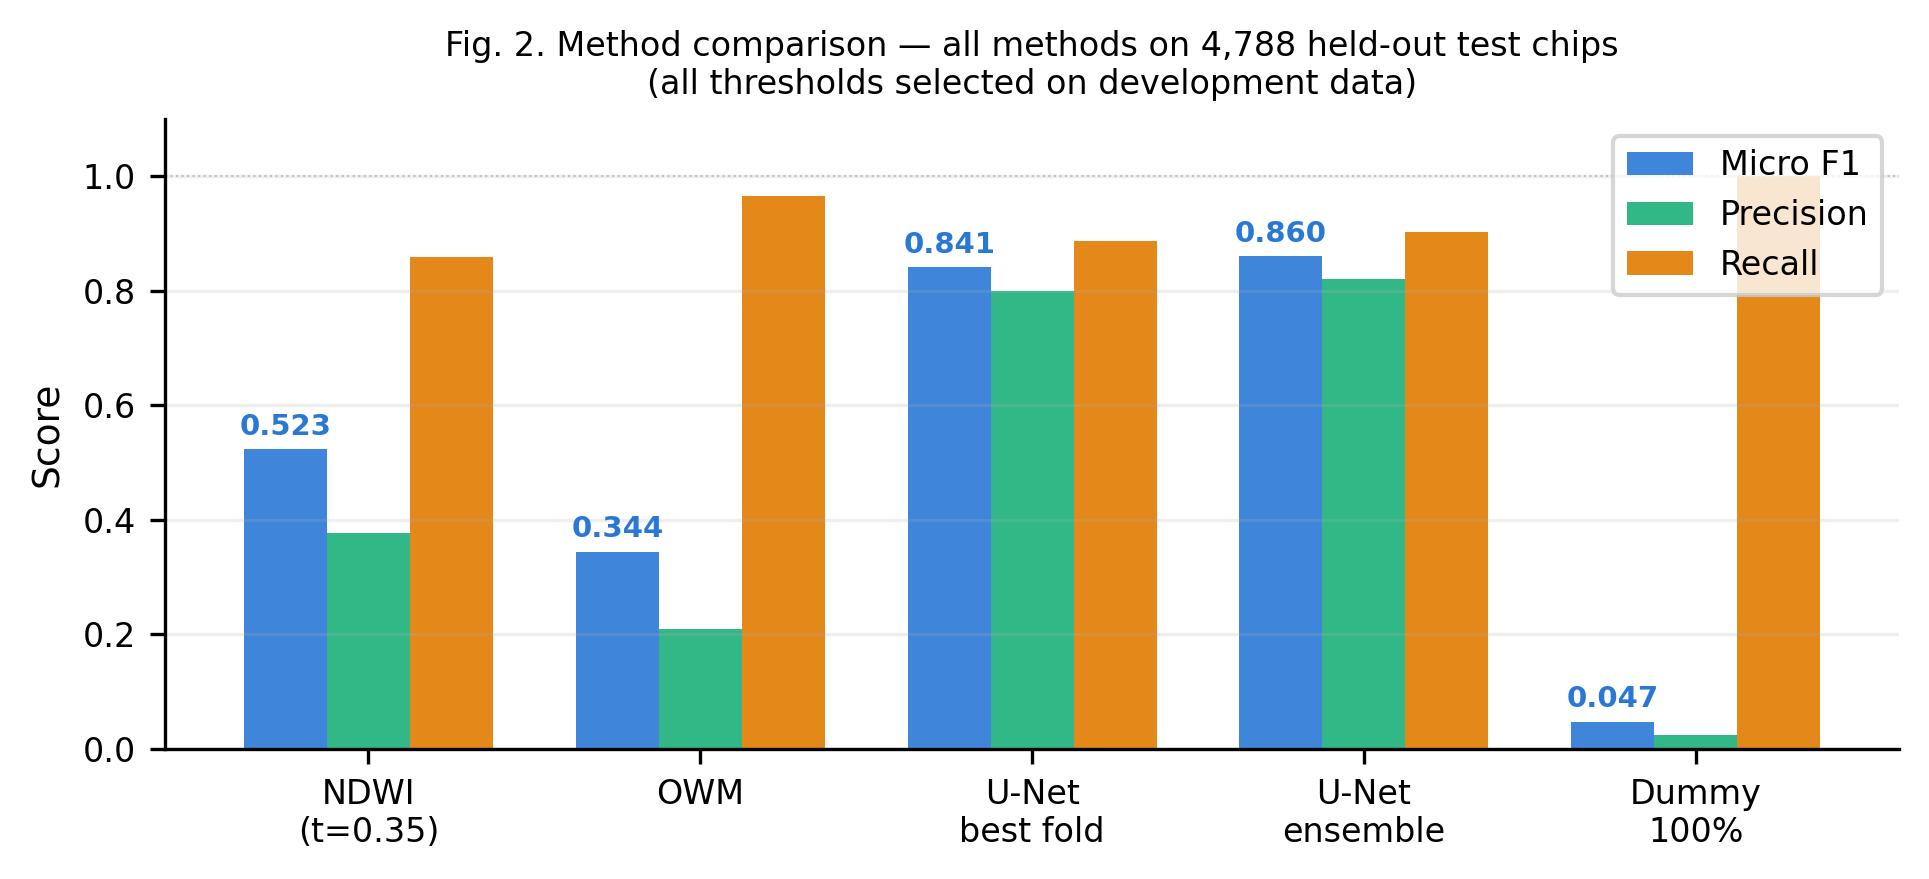

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_comparison.png


In [3]:
# ── Cell 3: Fig 2 — Method Comparison Bar Chart ──

methods = [
    'NDWI\n(t=0.35)',
    'OWM',
    'U-Net\nbest fold',
    'U-Net\nensemble',
    'Dummy\n100%',
]
f1   = [0.5230, 0.3440, 0.8413, 0.8601, 0.0472]
prec = [0.3760, 0.2090, 0.7995, 0.8205, 0.0242]
rec  = [0.8590, 0.9660, 0.8877, 0.9036, 1.0000]

x     = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(6.5, 3.0))
bars_f1   = ax.bar(x - width, f1,   width, label='Micro F1',  color=BLUE,   alpha=0.9)
bars_prec = ax.bar(x,         prec, width, label='Precision', color=GREEN,  alpha=0.9)
bars_rec  = ax.bar(x + width, rec,  width, label='Recall',    color=ORANGE, alpha=0.9)

for bar, val in zip(bars_f1, f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7,
            fontweight='bold', color=BLUE)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=8)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title(
    'Fig. 2. Method comparison — all methods on 4,788 held-out test chips\n'
    '(all thresholds selected on development data)',
    fontsize=8
)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.2)
ax.axhline(1.0, color=LGRAY, lw=0.5, linestyle=':')

plt.tight_layout()
out2 = OUT_DIR / 'fig_comparison.png'
plt.savefig(out2, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

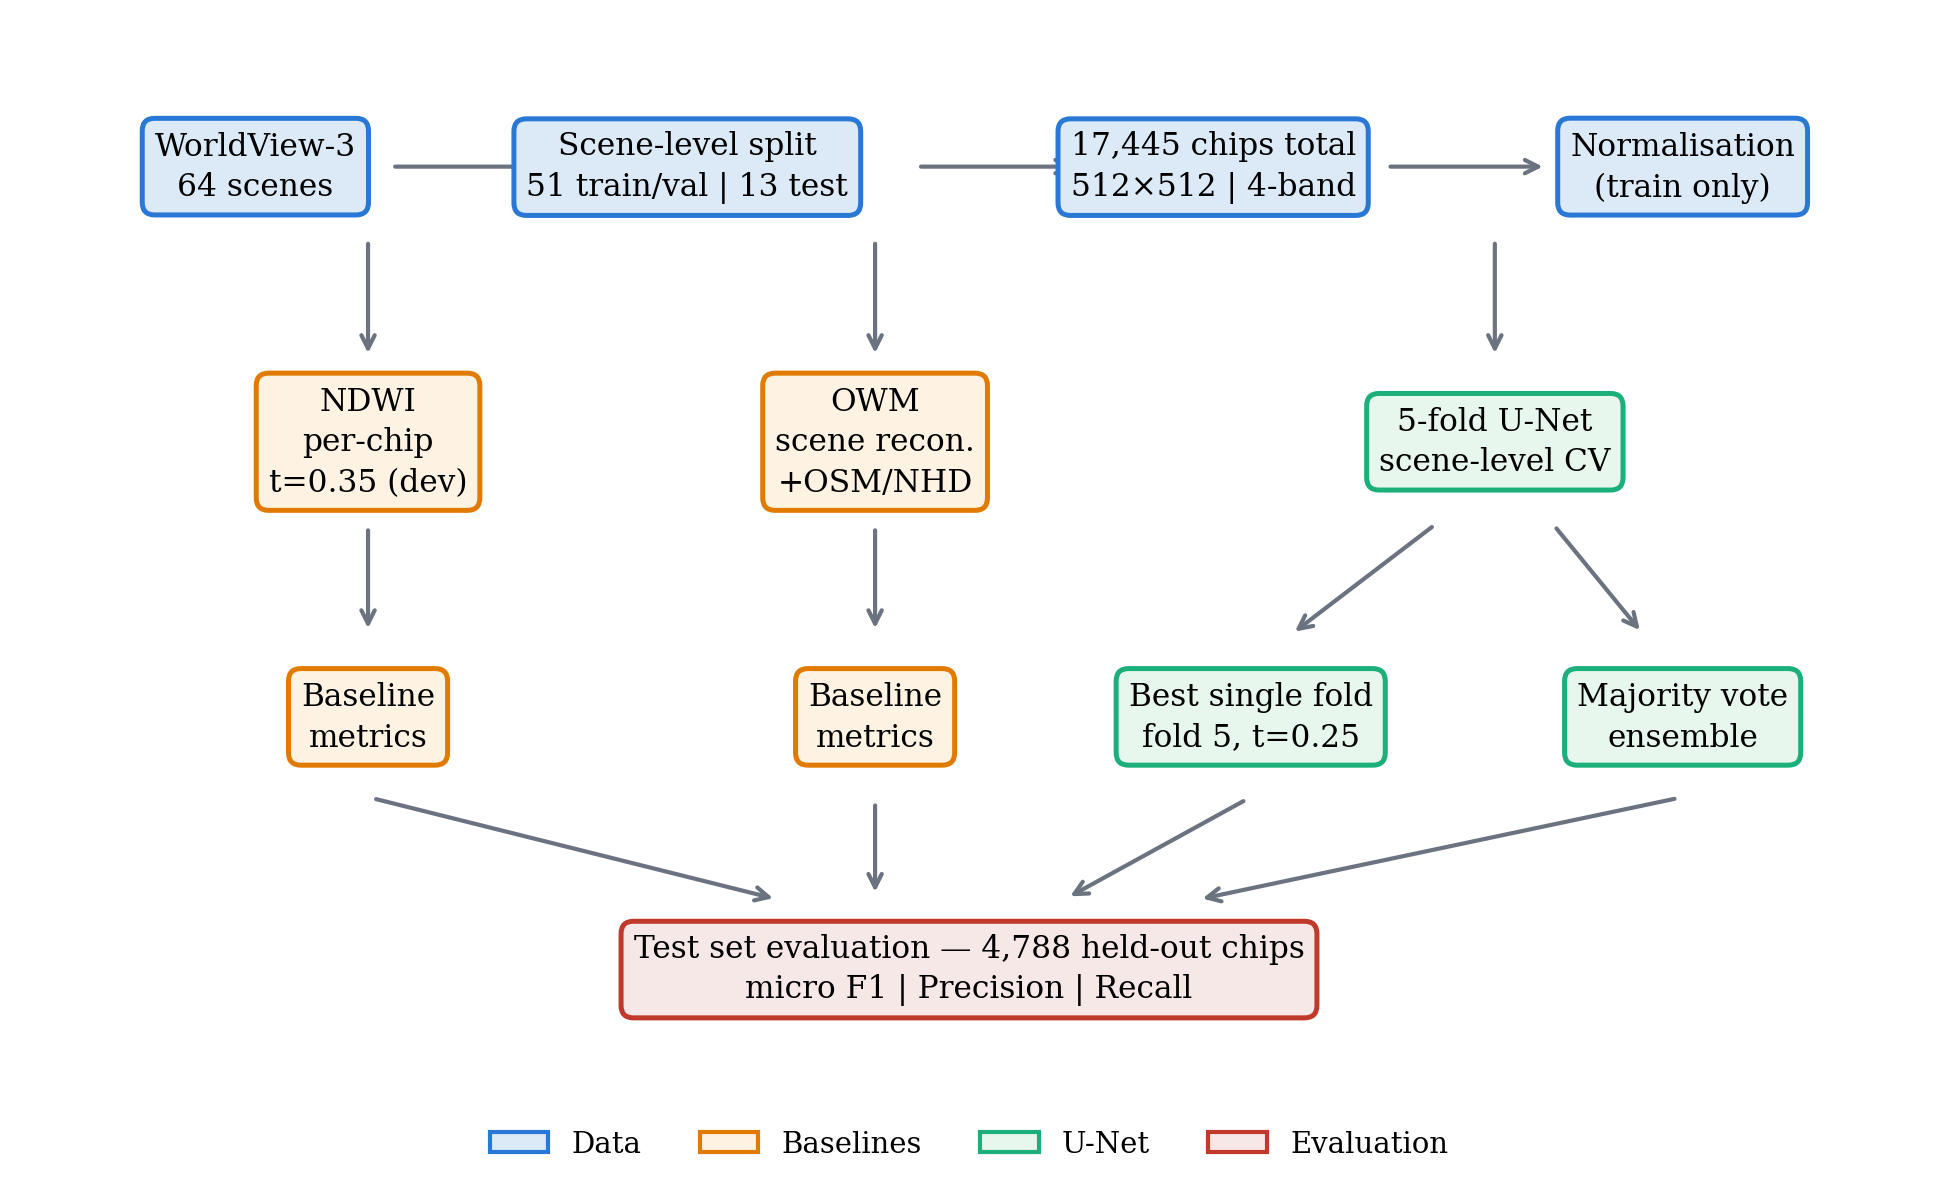

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_pipeline.png


In [18]:
# ── Cell 4: Fig 3 — Pipeline Overview Diagram ──

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 4.0)
ax.axis('off')

box_style      = dict(boxstyle='round,pad=0.4', facecolor='#dce9f7', edgecolor='#2a78d6', linewidth=1.2)
baseline_style = dict(boxstyle='round,pad=0.4', facecolor='#fef3e2', edgecolor='#e07b00', linewidth=1.2)
unet_style     = dict(boxstyle='round,pad=0.4', facecolor='#e8f7ee', edgecolor='#1baf7a', linewidth=1.2)
result_style   = dict(boxstyle='round,pad=0.4', facecolor='#f7e8e8', edgecolor='#c0392b', linewidth=1.2)

def box(x, y, text, style, fs=7.5):
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            bbox=style, zorder=3, linespacing=1.4)

def arrow_h(x1, x2, y):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.0))

def arrow_v(x, y_start, y_end):
    ax.annotate('', xy=(x, y_end), xytext=(x, y_start),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.0))

def arrow_d(x1, y_start, x2, y_end):
    ax.annotate('', xy=(x2, y_end), xytext=(x1, y_start),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.0))

# ── Row 1: Data (y=3.4) ──
box(1.2, 3.4, 'WorldView-2/3\n64 scenes', box_style)
arrow_h(1.9, 2.8, 3.4)
box(3.5, 3.4, 'Scene-level split\n51 train/val | 13 test', box_style)
arrow_h(4.7, 5.6, 3.4)
box(6.3, 3.4, '17,445 chips total\n512×512 | 4-band', box_style)
arrow_h(7.2, 8.1, 3.4)
box(8.8, 3.4, 'Normalisation\n(train only)', box_style)

# ── Row 2: Methods (y=2.2) ──
box(1.8, 2.2, 'NDWI\nper-chip\nt=0.35 (dev)', baseline_style)
box(4.5, 2.2, 'OWM\nscene recon.\n+OSM/NHD', baseline_style)
box(7.8, 2.2, '5-fold U-Net\nscene-level CV', unet_style)

# Arrows: data → methods (top to bottom)
arrow_v(1.8, 3.1, 2.55)
arrow_v(4.5, 3.1, 2.55)
arrow_v(7.8, 3.1, 2.55)

# ── Row 3: Strategies (y=1.0) ──
box(1.8, 1.0, 'Baseline\nmetrics', baseline_style)
box(4.5, 1.0, 'Baseline\nmetrics', baseline_style)
box(6.5, 1.0, 'Best single fold\nfold 5, t=0.25', unet_style)
box(8.8, 1.0, 'Majority vote\nensemble', unet_style)

# Arrows: methods → strategies (top to bottom)
arrow_v(1.8, 1.85, 1.35)
arrow_v(4.5, 1.85, 1.35)
arrow_d(7.5, 1.85, 6.7, 1.35)
arrow_d(8.1, 1.85, 8.6, 1.35)

# ── Row 4: Test evaluation (y=-0.1) ──
box(5.0, -0.1, 'Test set evaluation — 4,788 held-out chips\nmicro F1 | Precision | Recall', result_style, fs=7.5)

# Arrows: strategies → test (top to bottom)
arrow_d(1.8, 0.65, 4.0, 0.20)
arrow_d(4.5, 0.65, 4.5, 0.20)
arrow_d(6.5, 0.65, 5.5, 0.20)
arrow_d(8.8, 0.65, 6.2, 0.20)

# ── Legend ──
legend_elements = [
    mpatches.Patch(facecolor='#dce9f7', edgecolor='#2a78d6', label='Data'),
    mpatches.Patch(facecolor='#fef3e2', edgecolor='#e07b00', label='Baselines'),
    mpatches.Patch(facecolor='#e8f7ee', edgecolor='#1baf7a', label='U-Net'),
    mpatches.Patch(facecolor='#f7e8e8', edgecolor='#c0392b', label='Evaluation'),
]
ax.legend(handles=legend_elements, loc='lower center', fontsize=7,
          bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)

plt.tight_layout()
out3 = OUT_DIR / 'fig_pipeline.png'
plt.savefig(out3, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out3}')

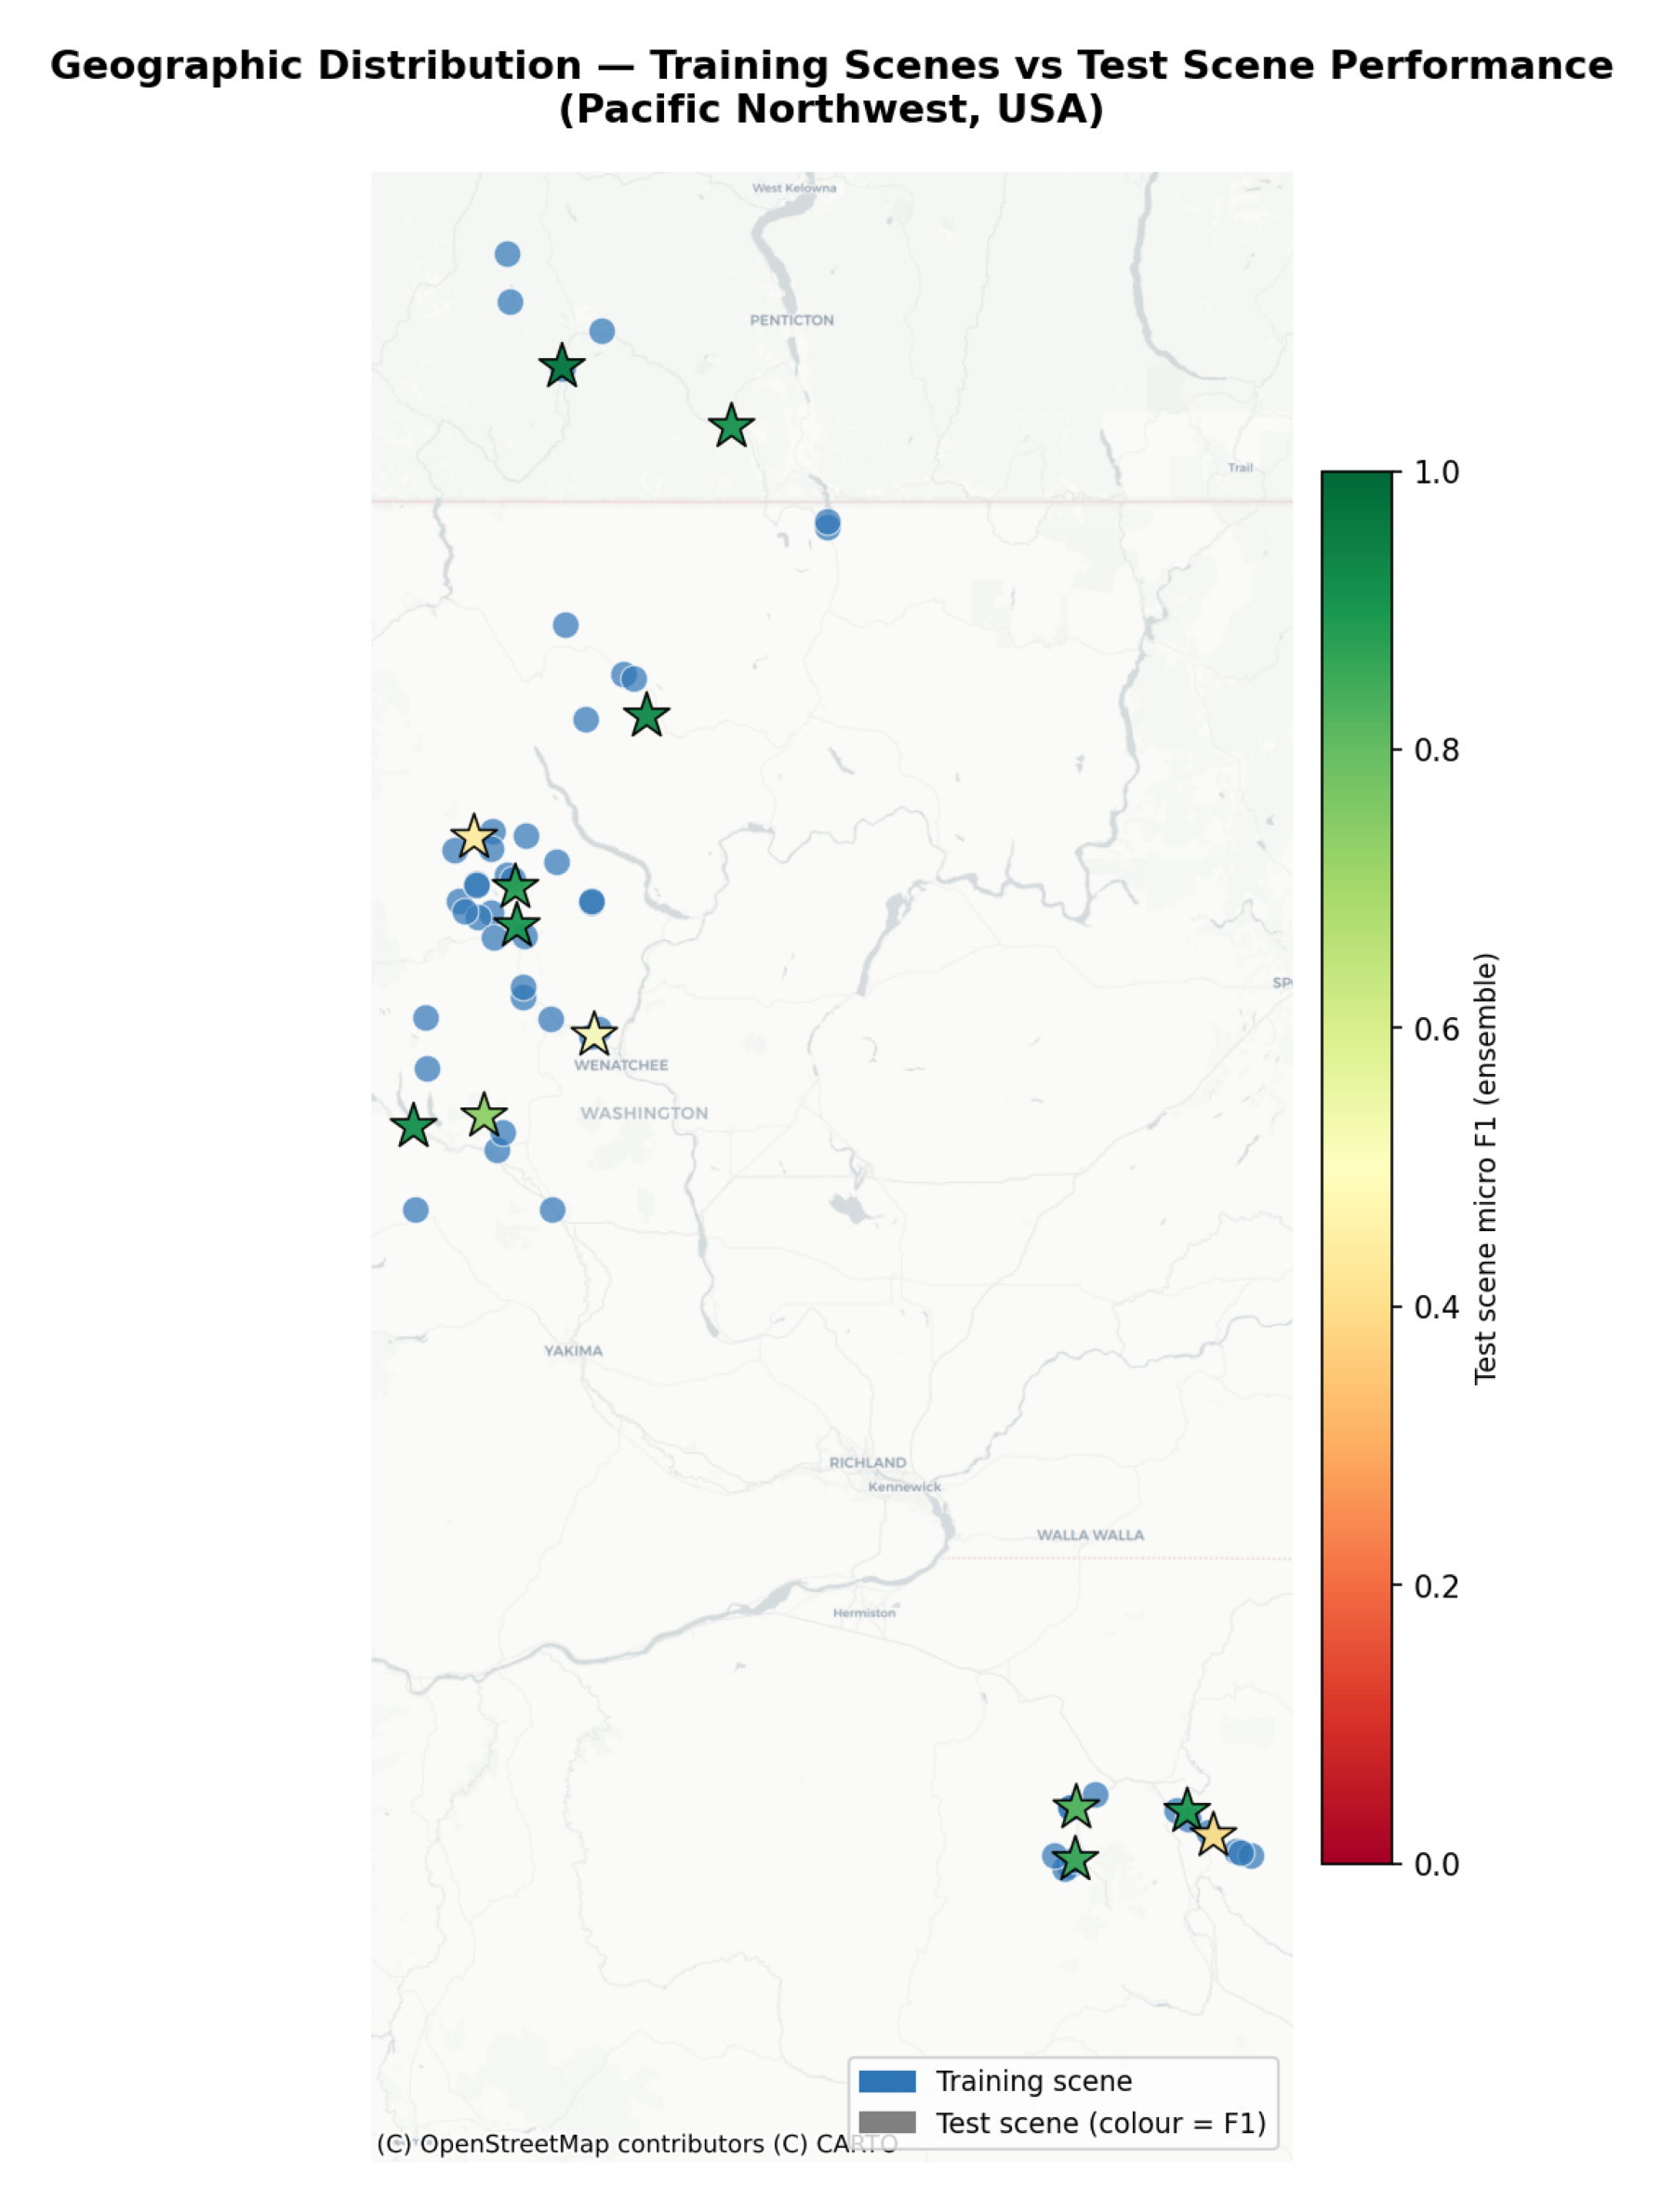

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_map.png


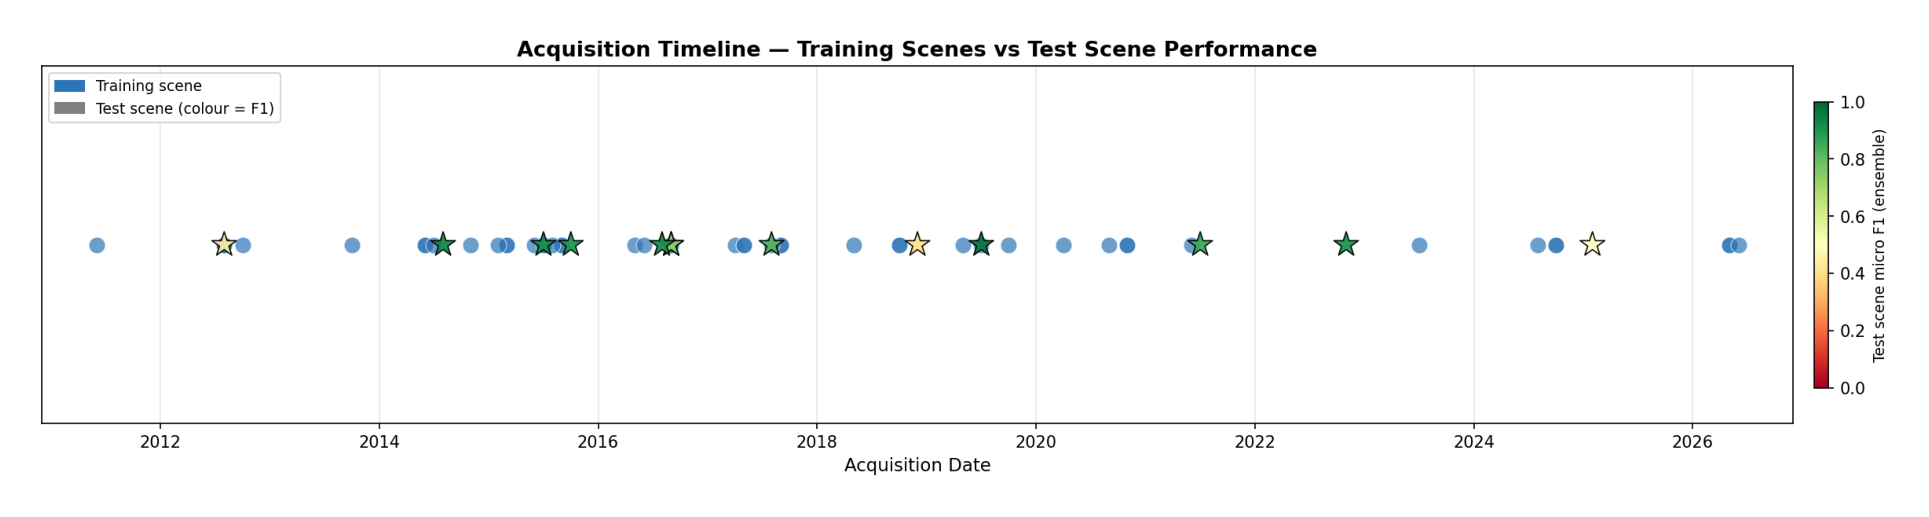

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_timeline.png


In [10]:
# ── Cell 5: Fig 4 — Map + Timeline (separate figures) ──
# Loads pre-generated figures from unet_diagnostic_final.ipynb (Cell 8).
# Saves map and timeline as separate files for dissertation.

from PIL import Image

map_path      = DIAG_DIR / 'fig_map_performance.png'
timeline_path = DIAG_DIR / 'fig_timeline_performance.png'

if not map_path.exists() or not timeline_path.exists():
    print(f'WARNING: Map or timeline figure not found.')
    print(f'  Map:      {map_path.exists()} — {map_path}')
    print(f'  Timeline: {timeline_path.exists()} — {timeline_path}')
    print('Run Cell 8 of unet_diagnostic_final.ipynb first.')
else:
    map_img      = Image.open(map_path)
    timeline_img = Image.open(timeline_path)

    # Save map separately — wide for double-column in dissertation
    fig, ax = plt.subplots(figsize=(13.0, 8.0))
    ax.imshow(map_img); ax.axis('off')
    plt.tight_layout()
    out_map = OUT_DIR / 'fig_map.png'
    plt.savefig(out_map, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_map}')

    # Save timeline separately — single column
    fig, ax = plt.subplots(figsize=(6.5, 2.5))
    ax.imshow(timeline_img); ax.axis('off')
    plt.tight_layout()
    out_timeline = OUT_DIR / 'fig_timeline.png'
    plt.savefig(out_timeline, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_timeline}')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

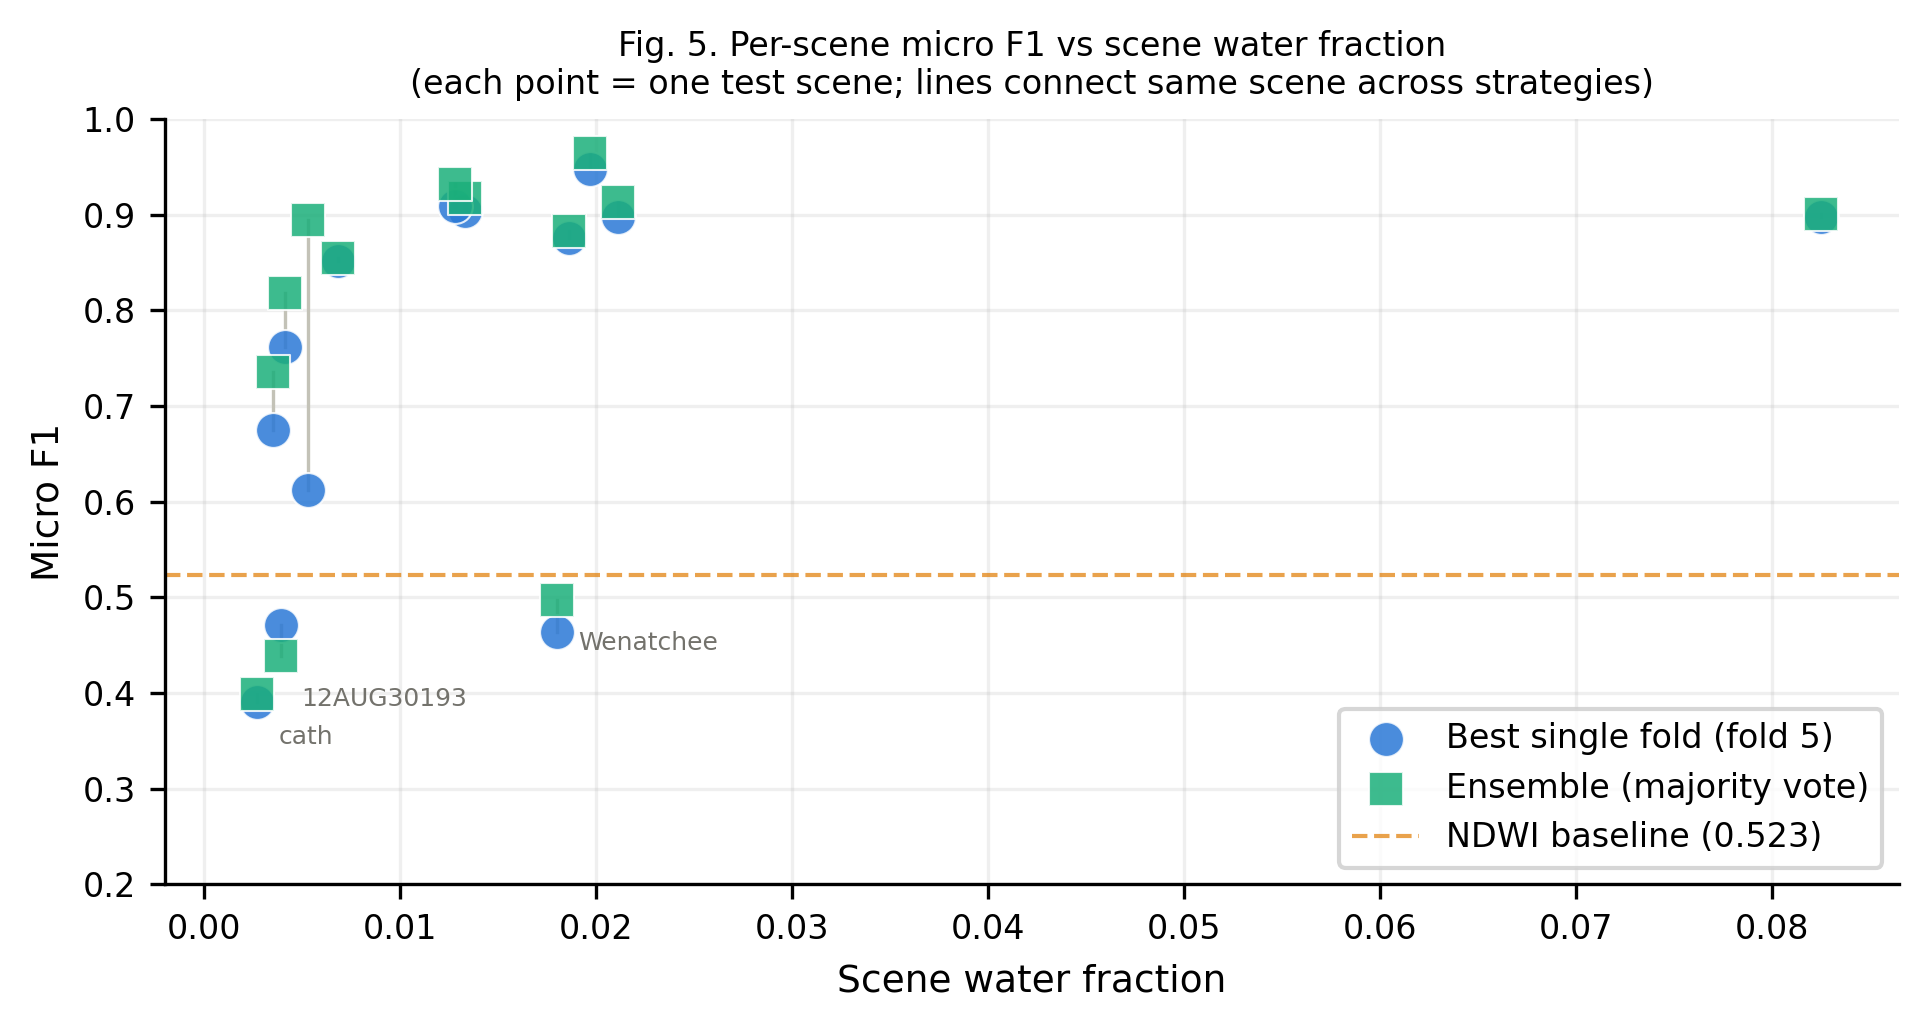

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_per_scene_scatter.png


In [7]:
# ── Cell 6: Fig 5 — Per-Scene F1 vs Water Fraction Scatter ──

scene_best = pd.read_csv(DIAG_DIR / 'per_scene_best_model.csv')
scene_ens  = pd.read_csv(DIAG_DIR / 'per_scene_ensemble.csv')

fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.scatter(scene_best['water_frac'], scene_best['micro_f1'],
           color=BLUE, alpha=0.85, s=70, marker='o',
           label='Best single fold (fold 5)', zorder=3,
           edgecolors='white', linewidths=0.5)

ax.scatter(scene_ens['water_frac'], scene_ens['micro_f1'],
           color=GREEN, alpha=0.85, s=70, marker='s',
           label='Ensemble (majority vote)', zorder=3,
           edgecolors='white', linewidths=0.5)

# Connect paired points with light lines
for _, row_b in scene_best.iterrows():
    row_e = scene_ens[scene_ens['scene'] == row_b['scene']]
    if not row_e.empty:
        ax.plot([row_b['water_frac'], row_e.iloc[0]['water_frac']],
                [row_b['micro_f1'],   row_e.iloc[0]['micro_f1']],
                color=LGRAY, lw=0.8, zorder=2)

# Annotate worst scenes
for _, row in scene_ens[scene_ens['micro_f1'] < 0.55].iterrows():
    ax.annotate(row['scene'].split('_')[0][:10],
                xy=(row['water_frac'], row['micro_f1']),
                xytext=(5, -12), textcoords='offset points',
                fontsize=6, color=GRAY)

ax.axhline(0.523, color=ORANGE, linestyle='--', lw=1.0, alpha=0.7,
           label='NDWI baseline (0.523)')
ax.set_xlabel('Scene water fraction')
ax.set_ylabel('Micro F1')
ax.set_title(
    'Fig. 5. Per-scene micro F1 vs scene water fraction\n'
    '(each point = one test scene; lines connect same scene across strategies)',
    fontsize=8
)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
ax.set_xlim(-0.002, None)
ax.set_ylim(0.2, 1.0)

plt.tight_layout()
out5 = OUT_DIR / 'fig_per_scene_scatter.png'
plt.savefig(out5, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out5}')

Best: Wenatchee_2019_07_26_104001004E554F00_AOI_1_clip_row10752_col1536.tif (water frac=0.7368)
Worst: cath_creek_2018_12_05_1040010046BF9000_AOI_1_clip_row8192_col8192.tif (water frac=0.0614)
Confounded: 16Sep2219_1b_Teanaway_clipped_row10752_col9216.tif (water frac=0.0749)


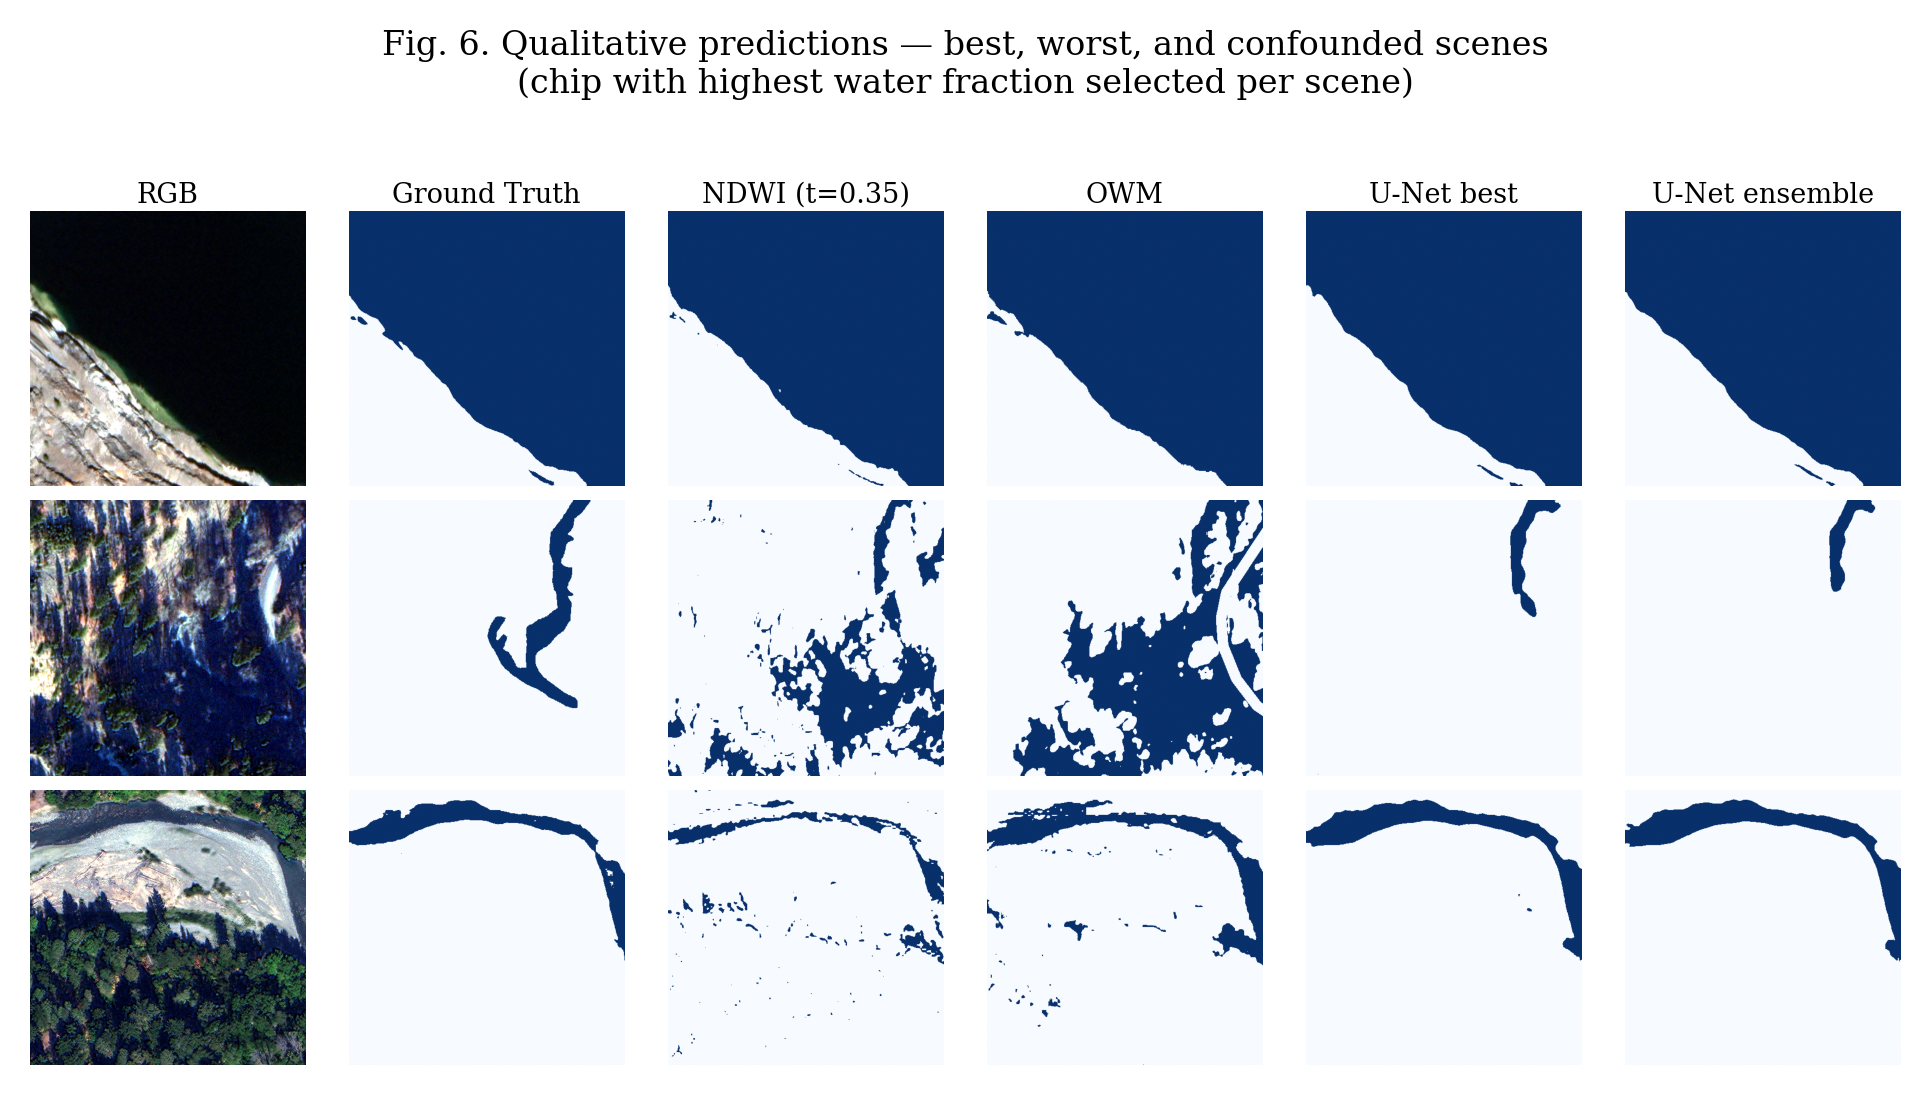

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_qualitative.png


In [24]:
# ── Cell 7: Fig 6 — Qualitative Predictions Panel ──
# Three scenes: best (Wenatchee_2019), worst (cath_creek_2018),
# confounded (16Sep2219_1b_Teanaway)
# Selects chip with highest water fraction per scene.
# Columns: RGB | Ground Truth | NDWI | OWM | U-Net best | U-Net ensemble

import json

with open(BASE_DIR / 'results/unet_training/test_chips.json') as f:
    test_chip_names = json.load(f)
test_chips = [CHIPS_DIR / n for n in test_chip_names]

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

SCENES = {
    'Best\n(F1=0.965)':       'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Worst\n(F1=0.399)':      'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
    'Confounded\n(F1=0.736)': '16Sep2219_1b_Teanaway',
}

THRESH_BEST = 0.25
COL_TITLES = ['RGB', 'Ground Truth', 'NDWI (t=0.35)', 'OWM', 'U-Net best', 'U-Net ensemble']

def stretch(arr):
    p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
    if (p98 - p2) < 1:
        return np.clip(arr / max(arr.max(), 1) * 255, 0, 255).astype(np.uint8)
    return np.clip((arr-p2)/(p98-p2)*255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(3, 6, figsize=(6.5, 3.5))

for row_idx, (scene_label, scene_id) in enumerate(SCENES.items()):
    # Pick chip with highest water fraction from scene
    scene_chips = [c for c in test_chips if get_scene_id(c.name) == scene_id]
    best_chip = None
    best_wf   = -1
    for cp in scene_chips:
        if not (PROB_DIR_BEST / cp.name).exists(): continue
        if not (PRED_DIR_MAJORITY / cp.name).exists(): continue
        if not (MASKS_DIR / cp.name).exists(): continue
        with rasterio.open(MASKS_DIR / cp.name) as src:
            wf = float((src.read(1) > 0).mean())
        if wf > best_wf:
            best_wf   = wf
            best_chip = cp

    if best_chip is None:
        print(f'WARNING: No valid chip found for {scene_id}')
        continue

    print(f'{scene_label.split(chr(10))[0]}: {best_chip.name} (water frac={best_wf:.4f})')

    with rasterio.open(best_chip) as src:
        rgb = np.stack([stretch(src.read(5).astype(np.float32)),
                        stretch(src.read(3).astype(np.float32)),
                        stretch(src.read(2).astype(np.float32))], axis=-1)

    with rasterio.open(MASKS_DIR / best_chip.name) as src:
        truth = (src.read(1) > 0).astype(np.uint8)

    ndwi_path = NDWI_MASKS_DIR / best_chip.name
    ndwi = np.zeros((512, 512), dtype=np.uint8)
    if ndwi_path.exists():
        with rasterio.open(ndwi_path) as src: ndwi = src.read(1)

    owm = np.zeros((512, 512), dtype=np.uint8)
    owm_path = OWM_DIR / best_chip.name
    if owm_path.exists():
        with rasterio.open(owm_path) as src: owm = (src.read(1) > 0).astype(np.uint8)

    with rasterio.open(PROB_DIR_BEST / best_chip.name) as src:
        best = (src.read(1) >= THRESH_BEST).astype(np.uint8)

    with rasterio.open(PRED_DIR_MAJORITY / best_chip.name) as src:
        ens = src.read(1)

    panels = [rgb, truth, ndwi, owm, best, ens]
    cmaps  = [None, 'Blues', 'Blues', 'Blues', 'Blues', 'Blues']

    for col_idx, (panel, cmap) in enumerate(zip(panels, cmaps)):
        ax = axes[row_idx, col_idx]
        ax.imshow(panel, cmap=cmap, vmin=0, vmax=1 if cmap else None)
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx], fontsize=6.5, pad=2)
        if col_idx == 0:
            ax.set_ylabel(scene_label, fontsize=6.5, rotation=0,
                          labelpad=45, va='center')

plt.suptitle(
    'Fig. 6. Qualitative predictions — best, worst, and confounded scenes\n'
    '(chip with highest water fraction selected per scene)',
    fontsize=8, y=1.02
)
plt.tight_layout()
out6 = OUT_DIR / 'fig_qualitative.png'
plt.savefig(out6, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out6}')

In [9]:
# ── Cell 8: Summary ──
print('All figures saved to:', OUT_DIR)
for f in sorted(OUT_DIR.glob('fig_*.png')):
    print(f'  {f.name}')

All figures saved to: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures
  fig_comparison.png
  fig_map_timeline.png
  fig_per_scene_scatter.png
  fig_pipeline.png
  fig_qualitative.png
  fig_training_curves.png
